# Lab 3: Neural Networks

For this lab you will need to install a few more packages: torch, torchvision and tensorflow.  
Tip: copy the environment from the previous lab into a new one, and then install the new packages.  
Avoid messing p with a working environment due to possible version compatibility issues.  

## General imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib as mp
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch
import torchvision
import torchvision.transforms as T
from torchvision import models
from torchvision.io import read_image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
from torch.utils.data.sampler import SubsetRandomSampler

## Load dataset

Input Variables (X):
0. Number of times pregnant
1. Plasma glucose concentration at 2 hours in an oral glucose tolerance test
2. Diastolic blood pressure (mm Hg)
3. Triceps skin fold thickness (mm)
4. 2-hour serum insulin (mu U/ml)
5. Body mass index (weight in kg/(height in m)^2)
6. Diabetes pedigree function
7. Age (years)

Output Variables (y):
8. Class variable (0 or 1)

See: [source](https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/)

In [3]:
# load the dataset, split into input (X) and output (y) variables
dataset = np.loadtxt('pima-indians-diabetes.csv', delimiter=',')
dataset


array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

In [4]:
dataeset = pd.read_csv('pima-indians-diabetes.csv')
dataeset

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


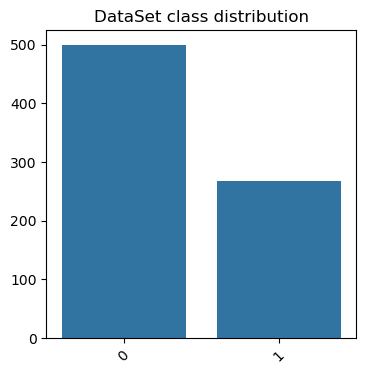

In [5]:
#plot class distribution
unique, counts = np.unique(dataeset['1'], return_counts=True)
plt.figure(figsize = (4,4))
ax = sns.barplot(x=unique,
                 y=counts).set_title('DataSet class distribution')
ticks = plt.xticks(rotation=45)

In [6]:

X = dataset[:,0:8]
y = dataset[:,8]

## Data cleaning and preparation

In this notebook we won't go through all the data preparation steps again, but focus on the NN.  
Remember to use all the resources you learned during labs 1 and 2 to understand, clean and prepare your data.

## Pytorch example

Transform the data in the correct input shape

In [7]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

Split dataset

In [8]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                              test_size=0.3, 
                                              random_state=42)

Define your model

In [9]:
# option 2
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(8, 12)
        self.act1 = nn.ReLU()
        self.hidden2 = nn.Linear(12, 8)
        self.act2 = nn.ReLU()
        self.output = nn.Linear(8, 1)
        self.act_output = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.hidden1(x))
        x = self.act2(self.hidden2(x))
        x = self.act_output(self.output(x))
        return x

model = Net()

In [10]:
print(model)

Net(
  (hidden1): Linear(in_features=8, out_features=12, bias=True)
  (act1): ReLU()
  (hidden2): Linear(in_features=12, out_features=8, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (act_output): Sigmoid()
)


In [11]:
# option 1
model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

In [12]:
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


### Define loss function

Tip:
On previous labs we used resampling to deal with imbalanced datasets.  
Another different of dealing with this imbalance is assigning class weights on the model's loss function.  
Use the parameter 'weight' in the loss function to deal with the imbalanced dataset  
See sklearn.utils.class_weight.compute_class_weight

In [13]:
# some examples
# criterion = nn.CrossEntropyLoss()
criterion = nn.BCELoss() # binary cross entropy
print (criterion)

BCELoss()


DATA AUGMENTATION

In [ ]:
# from imblearn.over_sampling import RandomOverSampler, SMOTE

# # Perform random oversampling
# # ros = RandomOverSampler(random_state=0)
# # X_train_resamp, y_train_resamp = ros.fit_resample(X_train, y_train)
# X_train_resamp, y_train_resamp = SMOTE().fit_resample(X_train, y_train)

In [ ]:
# #plot class distribution
# unique, counts = np.unique(y_train_resamp, return_counts=True)
# plt.figure(figsize = (4,4))
# ax = sns.barplot(x=unique,
#                  y=counts).set_title('DataSet class distribution')
# ticks = plt.xticks(rotation=45)

In [ ]:
# X_train = torch.tensor(X_train_resamp, dtype=torch.float32)
# y_train = torch.tensor(y_train_resamp, dtype=torch.float32).reshape(-1, 1)

Define optimizer

In [15]:
# some examples
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Train the model

Below, we perform a loop over epochs, where for each training epoch the code:

- Gets a batch of training data
- Zeros the optimizer’s gradients
- Performs an inference - that is, gets predictions from the model for an input batch
- Calculates the loss for that set of predictions vs. the labels on the dataset
- Calculates the backward gradients over the learning weights
- Tells the optimizer to perform one learning step - that is, adjust the model’s learning weights based on the observed gradients for this batch, according to the optimization algorithm we chose
- Reports on the loss for every 10 batches.

See: [source](https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#the-training-loop)

In [16]:
n_epochs = 500
batch_size = 20

training_losses = []
for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for count, i in enumerate(range(0, len(X_train), batch_size)):
        
        # get the inputs
        inputs = X_train[i:i+batch_size]
        labels = y_train[i:i+batch_size]

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = criterion(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if count % 10 == 9:    # print every 10 mini-batches
            last_loss = running_loss / 10
            print(f'[{epoch + 1}, {count + 1:5d}] loss: {running_loss / 10:.3f}')
            running_loss = 0.0

    training_losses.append(round(last_loss,3))

print('Finished Training')

[1,    10] loss: 4.231
[1,    20] loss: 2.449
[2,    10] loss: 1.312
[2,    20] loss: 1.029
[3,    10] loss: 0.721
[3,    20] loss: 0.779
[4,    10] loss: 0.716
[4,    20] loss: 0.724
[5,    10] loss: 0.683
[5,    20] loss: 0.707
[6,    10] loss: 0.668
[6,    20] loss: 0.691
[7,    10] loss: 0.661
[7,    20] loss: 0.679
[8,    10] loss: 0.647
[8,    20] loss: 0.669
[9,    10] loss: 0.638
[9,    20] loss: 0.663
[10,    10] loss: 0.630
[10,    20] loss: 0.656
[11,    10] loss: 0.624
[11,    20] loss: 0.649
[12,    10] loss: 0.617
[12,    20] loss: 0.641
[13,    10] loss: 0.607
[13,    20] loss: 0.636
[14,    10] loss: 0.602
[14,    20] loss: 0.633
[15,    10] loss: 0.597
[15,    20] loss: 0.632
[16,    10] loss: 0.595
[16,    20] loss: 0.630
[17,    10] loss: 0.590
[17,    20] loss: 0.627
[18,    10] loss: 0.588
[18,    20] loss: 0.625
[19,    10] loss: 0.586
[19,    20] loss: 0.623
[20,    10] loss: 0.581
[20,    20] loss: 0.619
[21,    10] loss: 0.578
[21,    20] loss: 0.618
[22,    10

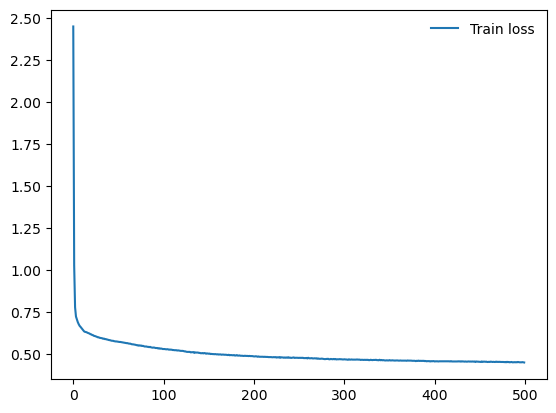

In [17]:
plt.plot(training_losses, label='Train loss')
plt.legend(frameon=False)
plt.show()

Save model

Tip: save the model with useful names that will help you identify it later on.

In [18]:
PATH = './pytorch_model.pth'
torch.save(model.state_dict(), PATH)

Evaluate model

In [19]:
# compute accuracy
with torch.no_grad():
    y_pred = model(X_test)

accuracy = (y_pred.round() == y_test).float().mean()
print(f"Accuracy {accuracy}")

Accuracy 0.7445887327194214


In [20]:
# make class predictions with the model
y_pred = (model(X_test) > 0.5).int() #binary classification
# print some predictions and true labels
for i in range(20):
    print(f'pred: {y_pred[i][0]} ; true {int(y_test[i])}')

pred: 1 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 0
pred: 1 ; true 0
pred: 0 ; true 1
pred: 1 ; true 0
pred: 0 ; true 1
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 1
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 1
pred: 0 ; true 1


Classification report

In [21]:
print(sk.metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.89      0.82       151
         1.0       0.70      0.46      0.56        80

    accuracy                           0.74       231
   macro avg       0.73      0.68      0.69       231
weighted avg       0.74      0.74      0.73       231



Is our model overfitting or underfitting?

In [22]:
model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

In [23]:
# try with fewer epochs
n_epochs = 100

In [24]:
for epoch in range(n_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    for count, i in enumerate(range(0, len(X_train), batch_size)):
        
        # get the inputs
        inputs = X_train[i:i+batch_size]
        labels = y_train[i:i+batch_size]

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = criterion(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

print('Finished Training')

Finished Training


In [25]:
# compute accuracy
with torch.no_grad():
    y_pred = model(X_test)

accuracy = (y_pred.round() == y_test).float().mean()
print(f"Accuracy {accuracy}")

Accuracy 0.7142857313156128


In [26]:
# make class predictions with the model
y_pred = (model(X_test) > 0.5).int() #binary classification
# print some predictions and true labels
for i in range(20):
    print(f'pred: {y_pred[i][0]} ; true {int(y_test[i])}')

pred: 1 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 0
pred: 0 ; true 1
pred: 1 ; true 0
pred: 0 ; true 1
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 1
pred: 0 ; true 0
pred: 0 ; true 0
pred: 1 ; true 1
pred: 0 ; true 1


In [27]:
print(sk.metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.73      0.89      0.80       151
         1.0       0.65      0.38      0.48        80

    accuracy                           0.71       231
   macro avg       0.69      0.63      0.64       231
weighted avg       0.70      0.71      0.69       231



Avoiding overfitting

Once per epoch perform validation by checking our relative loss on a set of data that was not used for training, and report this.  
This can be used to find a good number of epochs. Then, train a model on the full train dataset using this number of epochs.  
Here we use only one validation set.... what problems could this cause and how would you solve them?

In [28]:
model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

In [29]:

def train_one_epoch(X_train, y_train):

    running_loss = 0.0
    last_loss = 0.0
    for count, i in enumerate(range(0, len(X_train), batch_size)):
        
        # get the inputs
        inputs = X_train[i:i+batch_size]
        labels = y_train[i:i+batch_size]

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = criterion(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if count % 10 == 9:    # print every 10 mini-batches
            last_loss = running_loss / 10
            print(f'[{epoch + 1}, {count + 1:5d}] loss: {running_loss / 10:.3f}')
            running_loss = 0.0
    
    return last_loss

In [30]:
best_val_loss = 1_000_000.
n_epochs = 300
training_losses = []
val_losses = []

train_input, val_input, train_label, val_label = train_test_split(X_train, y_train,
                                            test_size=0.2, 
                                            random_state=42,
                                            )

for epoch in range(n_epochs):  # loop over the dataset multiple times

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)

    avg_loss = train_one_epoch(train_input, train_label)

    running_val_loss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    val_output = model(val_input)
    val_loss = criterion(val_output, val_label)
    running_val_loss += val_loss

    avg_val_loss = running_val_loss / (i + 1)
    print('LOSS train {} val {}'.format(avg_loss, avg_val_loss))

    # Track parameters
    training_losses.append(avg_loss)
    val_losses.append(avg_val_loss.detach().numpy())

    # Track best performance, and save the model's state
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model = {
            'epoch': epoch,
            'val_loss':best_val_loss
        }


[1,    10] loss: 2.008
[1,    20] loss: 1.592
LOSS train 1.5917845249176026 val 0.057703446596860886
[2,    10] loss: 1.015
[2,    20] loss: 0.864
LOSS train 0.864097285270691 val 0.03987745940685272
[3,    10] loss: 0.776
[3,    20] loss: 0.764
LOSS train 0.7644260287284851 val 0.035671498626470566
[4,    10] loss: 0.715
[4,    20] loss: 0.728
LOSS train 0.7277916133403778 val 0.03498106449842453
[5,    10] loss: 0.693
[5,    20] loss: 0.704
LOSS train 0.7036961615085602 val 0.03389495611190796
[6,    10] loss: 0.674
[6,    20] loss: 0.681
LOSS train 0.6805151581764222 val 0.03311511501669884
[7,    10] loss: 0.654
[7,    20] loss: 0.661
LOSS train 0.6611981987953186 val 0.03197016194462776
[8,    10] loss: 0.633
[8,    20] loss: 0.649
LOSS train 0.6488849520683289 val 0.031008269637823105
[9,    10] loss: 0.617
[9,    20] loss: 0.641
LOSS train 0.6406214356422424 val 0.030223753303289413
[10,    10] loss: 0.606
[10,    20] loss: 0.634
LOSS train 0.6338453352451324 val 0.0297160390764

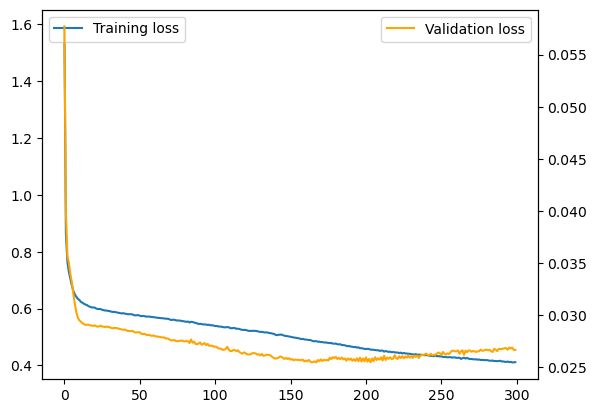

In [31]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(training_losses, label='Training loss')
ax2.plot(val_losses, label='Validation loss', color='orange')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

AUC-ROC

Get Probabilities from the Model

In [32]:
model.eval()

with torch.no_grad():
    y_scores = model(X_test).cpu().numpy().ravel()   # probabilities
    y_true = y_test.cpu().numpy().ravel()

Compute

In [33]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)

print(f"ROC AUC: {auc_score:.4f}")

ROC AUC: 0.7766


Plotting

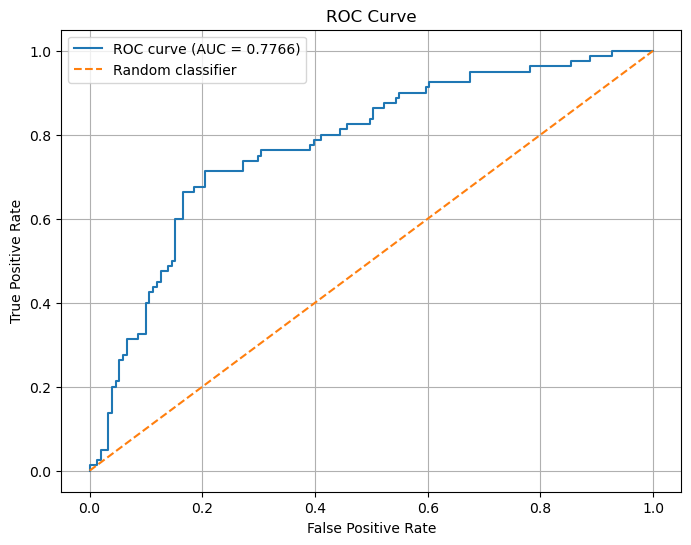

In [34]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Image classification example

See: [reference](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html).